In [22]:
#ROI Analysis of betting the underdog in every game.

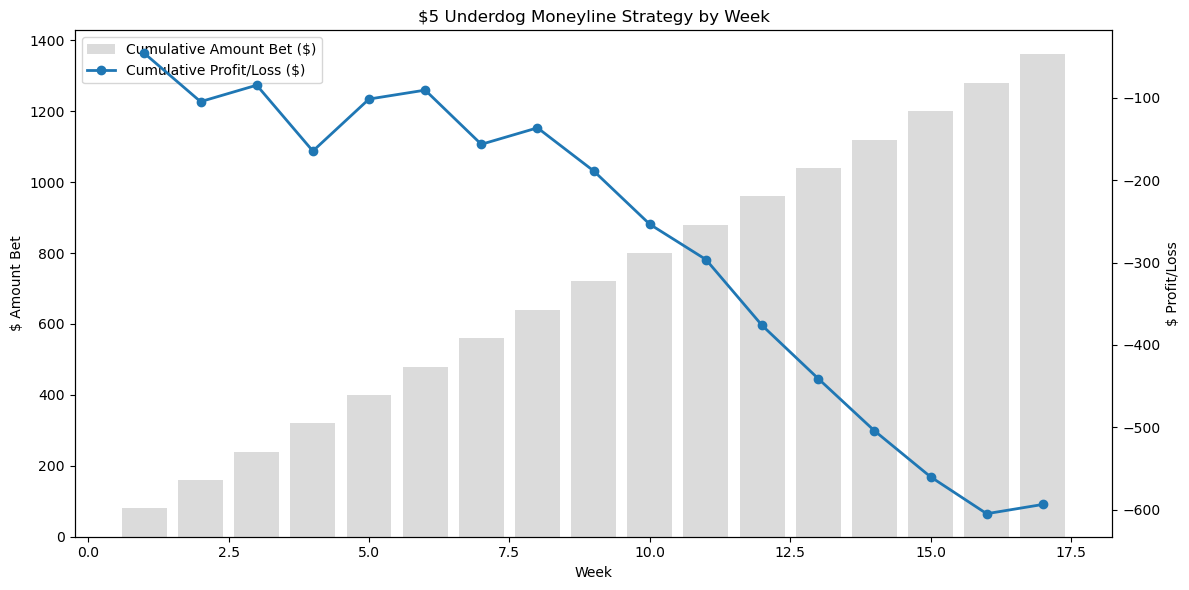

,week,weekly_profit_loss,weekly_bet_total,cumulative_profit_loss,cumulative_bet_total
0,1,-45.85,80.0,-45.85,80.0
1,2,-58.65,80.0,-104.50,160.0
2,3,20.00,80.0,-84.50,240.0
3,4,-80.00,80.0,-164.50,320.0
4,5,63.15,80.0,-101.35,400.0
5,6,10.85,80.0,-90.50,480.0
6,7,-65.80,80.0,-156.30,560.0
7,8,20.00,80.0,-136.30,640.0
8,9,-52.30,80.0,-188.60,720.0
9,10,-64.80,80.0,-253.40,800.0


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# File in repo root
file_path = "nfl_underdog_full_season.xlsx"

df = pd.read_excel(file_path)

# Normalize column names
normalized = {c: c.strip().lower().replace(" ", "_") for c in df.columns}


def find_col(candidates):
    """Find a matching column by exact or partial normalized name."""
    for original, norm in normalized.items():
        if norm in candidates:
            return original
    for original, norm in normalized.items():
        for cand in candidates:
            if cand in norm:
                return original
    return None

week_col = find_col({"week"})
underdog_col = find_col({"underdog_team", "underdog", "dog", "away_team", "team"})
underdog_ml_col = find_col({"underdog_moneyline", "moneyline", "ml", "underdog_ml"})
underdog_won_col = find_col({"underdog_won", "dog_won", "underdog_win"})

required = {
    "week": week_col,
    "underdog_team": underdog_col,
    "underdog_moneyline": underdog_ml_col,
    "underdog_won": underdog_won_col,
}

missing = [k for k, v in required.items() if v is None]
if missing:
    raise ValueError(
        f"Missing required columns: {missing}. Found columns: {list(df.columns)}"
    )

bets = df[[week_col, underdog_col, underdog_ml_col, underdog_won_col]].copy()
bets.columns = ["week", "underdog_team", "underdog_moneyline", "underdog_won"]

bets = bets.dropna(subset=["week", "underdog_team", "underdog_moneyline", "underdog_won"])
bets["week"] = pd.to_numeric(bets["week"], errors="coerce")
bets["underdog_moneyline"] = pd.to_numeric(bets["underdog_moneyline"], errors="coerce")
bets = bets.dropna(subset=["week", "underdog_moneyline"])

# Strategy: Bet $5 on every underdog moneyline
stake = 5.0


bets["bet_amount"] = stake
bets["underdog_won"] = bets["underdog_won"].astype(str).str.strip().str.lower().isin(["1", "true", "yes", "y"])
bets["profit_loss"] = bets.apply(
    lambda r: stake * (r["underdog_moneyline"] / 100.0) if r["underdog_won"] else -stake,
    axis=1,
)

weekly = (
    bets.groupby("week", as_index=False)
    .agg(weekly_profit_loss=("profit_loss", "sum"), weekly_bet_total=("bet_amount", "sum"))
    .sort_values("week")
)

weekly["cumulative_profit_loss"] = weekly["weekly_profit_loss"].cumsum()
weekly["cumulative_bet_total"] = weekly["weekly_bet_total"].cumsum()

# Plot: bars for cumulative amount bet, line for cumulative profit/loss
fig, ax1 = plt.subplots(figsize=(12, 6))

ax1.bar(
    weekly["week"],
    weekly["cumulative_bet_total"],
    color="lightgray",
    alpha=0.8,
    label="Cumulative Amount Bet ($)",
)
ax1.set_xlabel("Week")
ax1.set_ylabel("$ Amount Bet")

ax2 = ax1.twinx()
ax2.plot(
    weekly["week"],
    weekly["cumulative_profit_loss"],
    color="tab:blue",
    marker="o",
    linewidth=2,
    label="Cumulative Profit/Loss ($)",
)
ax2.set_ylabel("$ Profit/Loss")

# Legend
h1, l1 = ax1.get_legend_handles_labels()
h2, l2 = ax2.get_legend_handles_labels()
ax1.legend(h1 + h2, l1 + l2, loc="upper left")

plt.title("$5 Underdog Moneyline Strategy by Week")
plt.tight_layout()
plt.show()

weekly

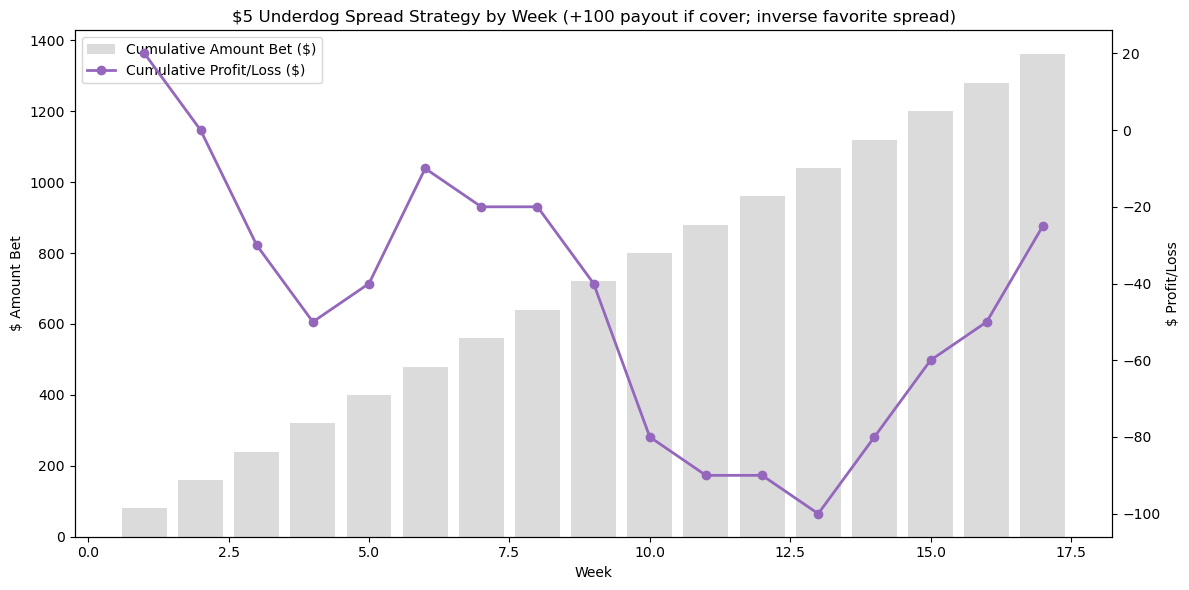

,week,weekly_profit_loss,weekly_bet_total,cumulative_profit_loss,cumulative_bet_total
0,1,20.0,80.0,20.0,80.0
1,2,-20.0,80.0,0.0,160.0
2,3,-30.0,80.0,-30.0,240.0
3,4,-20.0,80.0,-50.0,320.0
4,5,10.0,80.0,-40.0,400.0
5,6,30.0,80.0,-10.0,480.0
6,7,-10.0,80.0,-20.0,560.0
7,8,0.0,80.0,-20.0,640.0
8,9,-20.0,80.0,-40.0,720.0
9,10,-40.0,80.0,-80.0,800.0


In [ ]:
# Essentially repoliate the above analysis but using the spread instead of the moneyline.

week_col = find_col({"week"})
spread_col = find_col({"spread", "favorite_spread", "line"})
favorite_score_col = find_col({"favorite_score", "fav_score"})
underdog_score_col = find_col({"underdog_score", "dog_score"})
required_cols = {
    "week": week_col,
    "spread": spread_col,
    "favorite_score": favorite_score_col,
    "underdog_score": underdog_score_col,
}
missing_cols = [k for k, v in required_cols.items() if v is None]
if missing_cols:
    raise ValueError(f"Missing required columns: {missing_cols}. Found columns: {list(df.columns)}")

spread_bets = df[[week_col, spread_col, favorite_score_col, underdog_score_col]].copy()
spread_bets.columns = ["week", "favorite_spread", "favorite_score", "underdog_score"]

spread_bets["week"] = pd.to_numeric(spread_bets["week"], errors="coerce")
spread_bets["favorite_spread"] = pd.to_numeric(spread_bets["favorite_spread"], errors="coerce")
spread_bets["favorite_score"] = pd.to_numeric(spread_bets["favorite_score"], errors="coerce")
spread_bets["underdog_score"] = pd.to_numeric(spread_bets["underdog_score"], errors="coerce")
spread_bets = spread_bets.dropna()

# Spread is listed from favorite perspective, so invert for underdog.
spread_bets["underdog_spread"] = -spread_bets["favorite_spread"]
spread_bets["adjusted_dog_score"] = spread_bets["underdog_score"] + spread_bets["underdog_spread"]
spread_bets["underdog_covers"] = spread_bets["adjusted_dog_score"] > spread_bets["favorite_score"]
spread_bets["push"] = spread_bets["adjusted_dog_score"] == spread_bets["favorite_score"]

stake = 5.0
spread_bets["bet_amount"] = stake

# Spread bets at +100 (even money): profit on a win equals the stake.
win_profit = stake * (100 / 100.0)
spread_bets["profit_loss"] = spread_bets.apply(
    lambda r: 0.0 if r["push"] else (win_profit if r["underdog_covers"] else -stake),
    axis=1,
)

weekly_spread_inverse = (
    spread_bets.groupby("week", as_index=False)
    .agg(weekly_profit_loss=("profit_loss", "sum"), weekly_bet_total=("bet_amount", "sum"))
    .sort_values("week")
)

weekly_spread_inverse["cumulative_profit_loss"] = weekly_spread_inverse["weekly_profit_loss"].cumsum()
weekly_spread_inverse["cumulative_bet_total"] = weekly_spread_inverse["weekly_bet_total"].cumsum()

fig, ax1 = plt.subplots(figsize=(12, 6))
ax1.bar(
    weekly_spread_inverse["week"],
    weekly_spread_inverse["cumulative_bet_total"],
    color="lightgray",
    alpha=0.8,
    label="Cumulative Amount Bet ($)",
)
ax1.set_xlabel("Week")
ax1.set_ylabel("$ Amount Bet")

ax2 = ax1.twinx()
ax2.plot(
    weekly_spread_inverse["week"],
    weekly_spread_inverse["cumulative_profit_loss"],
    color="tab:purple",
    marker="o",
    linewidth=2,
    label="Cumulative Profit/Loss ($)",
)
ax2.set_ylabel("$ Profit/Loss")

h1, l1 = ax1.get_legend_handles_labels()
h2, l2 = ax2.get_legend_handles_labels()
ax1.legend(h1 + h2, l1 + l2, loc="upper left")

plt.title("$5 Underdog Spread Strategy by Week (+100 payout if cover; inverse favorite spread)")
plt.tight_layout()
plt.show()

weekly_spread_inverse